# 📓 Jupyter Notebook — Feature Showcase

This notebook demonstrates the core capabilities of Jupyter: **code execution**, **functions**, **plots**, **markdown**, **widgets**, and **data analysis**.

---

## 1. Roberto

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
import pandas as pd
from IPython.display import display

# Optional: nicer plots
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('All imports successful ✓')

ModuleNotFoundError: No module named 'numpy'

---
## 2. Andre

In [ ]:
# Basic variables and f-string formatting
name    = 'André'
pi      = np.pi
e       = np.e
phi     = (1 + np.sqrt(5)) / 2  # golden ratio

print(f'Hello, {name}!')
print(f'  π  = {pi:.6f}')
print(f'  e  = {e:.6f}')
print(f'  φ  = {phi:.6f}  (golden ratio)')

# Last expression is auto-displayed
np.array([pi, e, phi])

---
## 3. Duarte

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

#Constantes
nu = 1.48e-5 # Viscosidade cinemática do ar a 15graus 
rho = 1.22   # densidade

nome_ficheiro = "G06_XoD20.0000_R00_Freq34.5.txt"
with open(nome_ficheiro, 'r') as f:
    cabecalho = f.readline().strip()

# cabecaho
partes = cabecalho.replace('#', '').split(',')

XoD = float(partes[0].split('=')[1])
fs_texto = partes[1].split('=')[1].replace('kHz', '').strip()
fs = float(fs_texto) * 1000  # Passar de kHz para Hz
R = float(partes[2].split('=')[1].replace('mm', '').strip())
freq_forca = float(partes[3].split('=')[1].replace('Hz', '').strip())

dt = 1.0 / fs   # Calcular time step 

print(f"Posição (X/D): {XoD}")
print(f"Raio (R): {R} mm")
print(f"Frequência de Amostragem (fs): {fs} Hz  e time step dt: {dt} s")
print(f"Frequência de forçamento: {freq_forca} Hz")

# velocidade e tempo
u = np.loadtxt(nome_ficheiro, comments='#')
t = np.arange(len(u)) * dt

#Coisas da parte do roberto mas que eu preciso
U_media = np.mean(u)
u_linha = u - U_media          # perturbacoes
u_rms = np.std(u_linha)        # RMS das perturbacoes

print(f"Mean Velocity (U): {U_media:.2f} m/s")
print(f"Velocity RMS (u'): {u_rms:.3f} m/s")

# Derivada du/dt
du_dt = np.gradient(u_linha, dt)

# Conversao da derivada para derivada espacial usando a hipotese de taylor (dx = U * dt)
du_dx = du_dt / U_media

Posição (X/D): 20.0
Raio (R): 0.0 mm
Frequência de Amostragem (fs): 100000.0 Hz  e time step dt: 1e-05 s
Frequência de forçamento: 34.5 Hz
Mean Velocity (U): 10.49 m/s
Velocity RMS (u'): 2.368 m/s


In [34]:
#Escala de taylor e dissipacao
epsilon = 15 * nu * np.mean(du_dx**2) 
lambda_taylor = np.sqrt(15 * nu * (u_rms**2) / epsilon)
Re_lambda = (u_rms * lambda_taylor) / nu

print(f"Taxa de dissipação (epsilon): {epsilon:.2f} m^2/s^3")
print(f"Micro-escala de Taylor (lambda): {lambda_taylor*1000:.3f} mm")
print(f"Reynolds de Taylor (Re_lambda): {Re_lambda:.1f}")

Taxa de dissipação (epsilon): 290.09 m^2/s^3
Micro-escala de Taylor (lambda): 2.072 mm
Reynolds de Taylor (Re_lambda): 331.5


In [35]:
#Escala de Kolmogorov

eta = (nu**3 / epsilon)**0.25
u_eta = (nu * epsilon)**0.25
tau_eta = np.sqrt(nu / epsilon)

print(f"Comprimento de Kolmogorov (eta): {eta*1000:.4f} mm")
print(f"Escala de tempo de Kolmogorov (tau_eta): {tau_eta:.6f} s")
print(f"O time step da experiencia foi (dt):   {dt:.6f} s")

if dt < tau_eta:
    print("Logo, o time step é adequado (dt < tau_eta).")
else:
    print("Logo, o time step não é adequado (dt > tau_eta).")

Comprimento de Kolmogorov (eta): 0.0578 mm
Escala de tempo de Kolmogorov (tau_eta): 0.000226 s
O time step da experiencia foi (dt):   0.000010 s
Logo, o time step é adequado (dt < tau_eta).


In [36]:
#Autocorrelacao e integral length scale 
# Correlacionar o sinal com ele mesmo
autocorr = signal.correlate(u_linha, u_linha, mode='full')
autocorr = autocorr[autocorr.size // 2:] # Ficar so com a parte positiva
autocorr = autocorr / autocorr[0]        # Normalizar para começar em 1

atrasos = np.arange(len(autocorr)) * dt

# Encontrar onde a autocorrelacao passa pelo eixo pela primeira vez
indice_zero = np.where(autocorr < 0)[0][0]

# Integrar a área até ao primeiro zero para obter a escala integral de tempo
Tu = np.trapezoid(autocorr[:indice_zero], atrasos[:indice_zero])
Comprimento_Integral = U_media * Tu

print(f"Escala Integral de Tempo (Tu): {Tu:.5f} s")
print(f"Escala Integral de Comprimento (L): {Comprimento_Integral*1000:.2f} mm")

Escala Integral de Tempo (Tu): 0.00140 s
Escala Integral de Comprimento (L): 14.73 mm


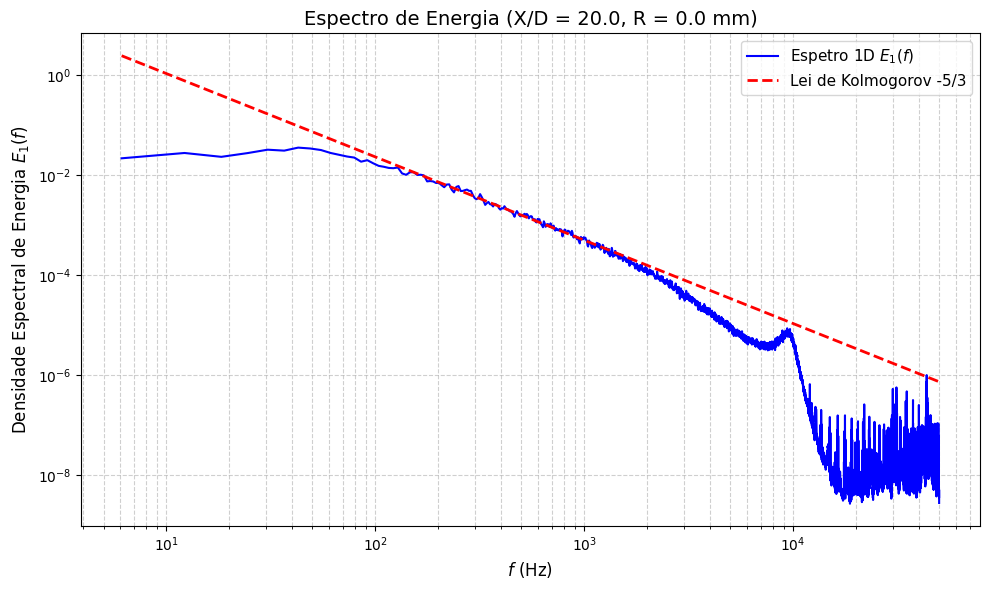

In [38]:
#Espectro de energia

frequencias, espetro = signal.welch(u_linha, fs, nperseg=2**14)
frequencias = frequencias[1:]
espetro = espetro[1:]

plt.figure(figsize=(10, 6))

# Espetro calculado
plt.loglog(frequencias, espetro, label='Espetro 1D $E_1(f)$', color='blue', linewidth=1.5)

# Linha da Lei -5/3 de Kolmogorov
indice_ancora = 50 
constante = espetro[indice_ancora] / (frequencias[indice_ancora]**(-5/3))
linha_53 = constante * (frequencias**(-5/3))
plt.loglog(frequencias, linha_53, 'r--', label='Lei de Kolmogorov -5/3', linewidth=2)

# Encontrar o ponto no gráfico correspondente à frequência de forçamento
idx_freq = np.argmin(np.abs(frequencias - freq_forca))
y_seta = espetro[idx_freq]


plt.xlabel('$f$ (Hz)', fontsize=12)
plt.ylabel('Densidade Espectral de Energia $E_1(f)$', fontsize=12)
plt.title(f'Espectro de Energia (X/D = {XoD}, R = {R} mm)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()